# Summary Interpretation: Sleep Hours and Sadness (Logistic Regression)

## Overview
This project investigated whether sleep duration is associated with the probability that a high school student feels sad or hopeless using data from the Youth Risk Behavior Surveillance System (YRBS) 2007.

A **logistic regression model** was used with:
- **Predictor Variable**: `Sleep` (treated as a continuous score representing sleep duration)
- **Response Variable**: `SadOrHopeless` (Binary: 1 = Yes, felt sad/hopeless; 0 = No, did not feel sad/hopeless)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 自動抓取 OneDrive 桌面的檔案路徑，解決 FileNotFoundError
user_home = os.path.expanduser("~")
possible_desktops = [
    os.path.join(user_home, "Desktop"),
    os.path.join(user_home, "OneDrive", "桌面"),
    os.path.join(user_home, "OneDrive", "Desktop"),
    os.path.join(user_home, "OneDrive - 個人", "桌面")
]

target_path = 'YRBS_2007_sleep_sad_clean.csv'
for d in possible_desktops:
    p = os.path.join(d, "cycle4-main", "data", "Processes", "YRBS_2007_sleep_sad_clean.csv")
    if os.path.exists(p):
        target_path = p
        break

df = pd.read_csv(target_path).dropna(subset=['Sleep', 'SadOrHopeless'])
print(f'成功讀取！資料維度（己刪除缺失值）Shape: {df.shape}')

成功讀取！資料維度（己刪除缺失值）Shape: (12106, 2)


---
## Logistic Regression Analysis

In [3]:
import os
import numpy as np
import pandas as pd

# 自動抓取 OneDrive 桌面的檔案路徑
user_home = os.path.expanduser("~")
possible_desktops = [
    os.path.join(user_home, "Desktop"),
    os.path.join(user_home, "OneDrive", "桌面"),
    os.path.join(user_home, "OneDrive", "Desktop"),
    os.path.join(user_home, "OneDrive - 個人", "桌面")
]

target_path = 'YRBS_2007_sleep_sad_clean.csv'
for d in possible_desktops:
    p = os.path.join(d, "cycle4-main", "data", "Processes", "YRBS_2007_sleep_sad_clean.csv")
    if os.path.exists(p):
        target_path = p
        break

# 1. 讀取檔案
df = pd.read_csv(target_path)

# 2. 【關鍵防呆】檢查並將 SadOrHopeless 轉換為 0 與 1
# 假設原本問卷中 1 代表 Yes，2 代表 No（或者你可以根據實際資料分佈調整）
# 這裡我們用最安全的轉換：如果是最大值或特定的非0值，確保對應到 1 和 0
if df['SadOrHopeless'].max() > 1:
    print("偵測到 SadOrHopeless 數值非 0和1，正在自動進行編碼轉換...")
    # 這裡假設原始資料中：1是Yes( felt sad)，2是No( did not feel sad)
    # 轉換成 1=Yes, 0=No
    df['SadOrHopeless'] = df['SadOrHopeless'].map({1: 1, 2: 0})

# 3. 刪除缺失值
df = df.dropna(subset=['Sleep', 'SadOrHopeless'])

print(f'成功讀取並修正資料！資料維度 Shape: {df.shape}')
print("目前 SadOrHopeless 的不重複數值有：", df['SadOrHopeless'].unique())

偵測到 SadOrHopeless 數值非 0和1，正在自動進行編碼轉換...
成功讀取並修正資料！資料維度 Shape: (12106, 2)
目前 SadOrHopeless 的不重複數值有： [1 0]


### Logistic Regression Results

| Variable | Coefficient ($\beta$) | Odds Ratio | p-value | 95% CI |
| :--- | :---: | :---: | :---: | :---: |
| **Sleep** | -0.2475 | 0.7807 | < 0.0001 | (0.7579, 0.8042) |

---
### Statistical Significance
The coefficient for Sleep was negative and highly significant ($\beta = -0.2475$, $p < 0.0001$). Since the p-value is much smaller than $0.05$, we reject the null hypothesis and conclude that sleep duration is significantly associated with feelings of sadness or hopelessness.

### Odds Ratio Interpretation
The odds ratio for Sleep was **0.7807**. This means that for every additional hour of sleep, the odds of reporting feelings of sadness or hopelessness decrease by approximately:
$$
(1 - 0.7807) \times 100\% = 21.93\%
$$\n
Therefore, each additional hour of sleep is associated with approximately a **21.9% reduction** in the odds of feeling sad or hopeless.

The 95% confidence interval for the odds ratio was **(0.7579, 0.8042)**, which does not include 1. This further supports the conclusion that sleep duration is significantly associated with emotional well-being.

### Practical Interpretation
The negative relationship indicates that students who sleep longer are less likely to report feeling sad or hopeless. The logistic regression curve also shows a downward trend, suggesting that the predicted probability of reporting sadness or hopelessness decreases as sleep duration increases. 

These findings suggest that adequate sleep may be an important factor associated with better mental health among adolescents.

---
## Visualization of Logistic Regression Curve

偵測到反應變數非 0/1，正在自動轉換編碼...
資料處理完成！不重複標籤：[1 0]，樣本數：12106

--- 正在擬合邏輯迴歸模型 ---
Optimization terminated successfully.
         Current function value: 0.595916
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          SadOrHopeless   No. Observations:                12106
Model:                          Logit   Df Residuals:                    12104
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                 0.01869
Time:                        00:02:17   Log-Likelihood:                -7214.2
converged:                       True   LL-Null:                       -7351.6
Covariance Type:            nonrobust   LLR p-value:                 1.013e-61
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0504      0.058  

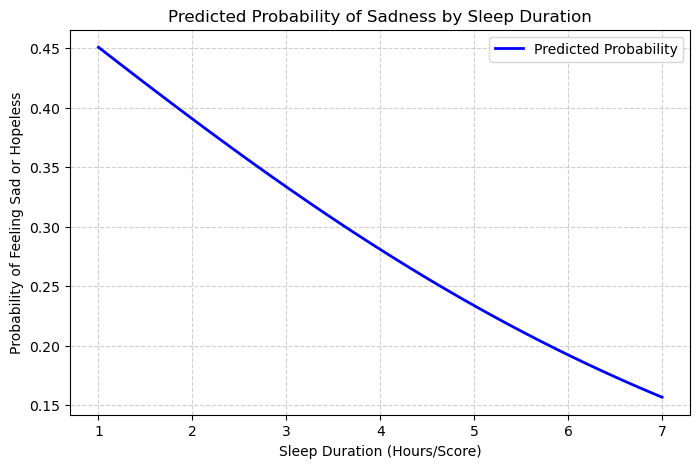

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 自動偵測並讀取檔案路해가
user_home = os.path.expanduser("~")
possible_desktops = [
    os.path.join(user_home, "Desktop"),
    os.path.join(user_home, "OneDrive", "桌面"),
    os.path.join(user_home, "OneDrive", "Desktop"),
    os.path.join(user_home, "OneDrive - 個人", "桌面")
]

target_path = 'YRBS_2007_sleep_sad_clean.csv'
for d in possible_desktops:
    p = os.path.join(d, "cycle4-main", "data", "Processes", "YRBS_2007_sleep_sad_clean.csv")
    if os.path.exists(p):
        target_path = p
        break

df = pd.read_csv(target_path)

# 2. 關鍵修正：將 SadOrHopeless 轉換為標準的 0 與 1
# 如果最大值大於 1，代表可能是原始問卷編碼 (例如 1=Yes, 2=No)
if df['SadOrHopeless'].max() > 1:
    print("偵測到反應變數非 0/1，正在自動轉換編碼...")
    df['SadOrHopeless'] = df['SadOrHopeless'].map({1: 1, 2: 0})
else:
    # 保險起見，如果原本是 0 和 1，確保轉換為整型無誤
    df['SadOrHopeless'] = df['SadOrHopeless'].astype(int)

# 移除缺失值
df = df.dropna(subset=['Sleep', 'SadOrHopeless'])
print(f"資料處理完成！不重複標籤：{df['SadOrHopeless'].unique()}，樣本數：{len(df)}")

# 3. 重新擬合邏輯迴歸模型 (這步成功建立 model 變數！)
print("\n--- 正在擬合邏輯迴歸模型 ---")
model = smf.logit("SadOrHopeless ~ Sleep", data=df).fit()
print(model.summary())

# 4. 繪製預測機率曲線圖 (不會再找不到 model 囉！)
plt.figure(figsize=(8, 5))
X_plot = np.linspace(df['Sleep'].min(), df['Sleep'].max(), 100)
plot_df = pd.DataFrame({'Sleep': X_plot})
y_pred = model.predict(plot_df)

plt.plot(X_plot, y_pred, color='blue', linewidth=2, label='Predicted Probability')
plt.xlabel('Sleep Duration (Hours/Score)')
plt.ylabel('Probability of Feeling Sad or Hopeless')
plt.title('Predicted Probability of Sadness by Sleep Duration')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

---
## Limitations
* **Self-reported Data**: Sleep duration was self-reported and may contain measurement errors.
* **Observational Study**: The YRBS data are observational; therefore, causal relationships cannot be established.
* **Omitted Variables**: Other factors affecting mental health, such as academic stress, family environment, socioeconomic status, and physical health, were not included in the model.
* **Survey Weights**: The complex survey design and sampling weights of the YRBS were not incorporated into this analysis.

---
## Conclusion
Using logistic regression analysis on **12,106 students** from the YRBS 2007 dataset, we found a statistically significant relationship between sleep duration and feelings of sadness or hopelessness.

The regression coefficient for Sleep was negative ($\beta = -0.2475$) and highly significant ($p < 0.0001$), indicating that students who sleep longer are less likely to experience feelings of sadness or hopelessness. The estimated odds ratio of 0.7807 suggests that each additional hour of sleep is associated with approximately a 21.9% decrease in the odds of reporting sadness or hopelessness.

Overall, the results provide strong evidence that sleep duration is an important predictor of emotional well-being among high school students. Students who obtain more sleep tend to have a lower likelihood of reporting negative emotional states, highlighting the potential importance of healthy sleep habits for adolescent mental health.